# ICU Mortality Prediction using Machine Learning

This notebook demonstrates
- Data preprocessing using MIMIC-IV dataset
- Feature engineering
- Model training (Logistic Regression, SMOTE, Random Forest)
- Evaluation using F1-score and AUROC

## Importing Required Modules

In [1]:
import pandas as pd

from modules.data_processor import PatientDataProcessor
from modules.model import MortalityPredictor

from modules.utils import (
    plot_mortality_distribution,
    plot_model_f1_scores,
    plot_mortality_by_age_group,
    plot_confusion_matrix,
    plot_feature_importance,
    export_model_results,
)

## Data Loading and Preprocessing

In [2]:
processor = PatientDataProcessor("data")

processor.load_data()
processor.merge_data()
processor.clean_data()
processor.feature_engineering()

print(processor)

df = processor.get_model_data()

print("\nMortality Distribution:")
print(df["mortality"].value_counts())

df.head()

Dataset with 140 records

Mortality Distribution:
mortality
0    120
1     20
Name: count, dtype: int64


,admission_age,gender_encoded,los,mortality
0,21,0,2.471169,0
1,75,0,16.069838,1
2,75,0,2.916701,1
3,75,0,12.911308,0
4,81,0,7.032894,0


## Mortality Distribution Visualization

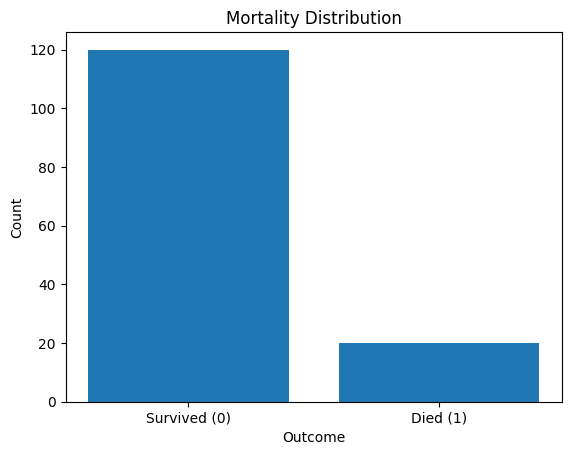

In [3]:
plot_mortality_distribution(df)

## Model Initialization

In [4]:
predictor = MortalityPredictor(processor)
predictor.split_data()

print(predictor)

MortalityPredictor with 140 samples


## Logistic Regression (Baseline Model)

In [5]:
predictor.train_logistic_regression()
lr_results = predictor.evaluate_model("logistic_regression")

print("Logistic Regression Results")
print("Accuracy:", lr_results["accuracy"])
print("F1 Score:", lr_results["f1_score"])
print("AUROC:", lr_results["auroc"])
print("Confusion Matrix:\n", lr_results["confusion_matrix"])
print(lr_results["classification_report"])

Logistic Regression Results
Accuracy: 0.8214285714285714
F1 Score: 0.0
AUROC: 0.46875
Confusion Matrix:
 [[23  1]
 [ 4  0]]
              precision    recall  f1-score   support

           0       0.85      0.96      0.90        24
           1       0.00      0.00      0.00         4

    accuracy                           0.82        28
   macro avg       0.43      0.48      0.45        28
weighted avg       0.73      0.82      0.77        28



## Logistic Regression with SMOTE

In [6]:
predictor.train_logistic_regression_smote()
smote_results = predictor.evaluate_model("logistic_regression_smote")

print("Logistic Regression + SMOTE Results")
print("Accuracy:", smote_results["accuracy"])
print("F1 Score:", smote_results["f1_score"])
print("AUROC:", smote_results["auroc"])
print("Confusion Matrix:\n", smote_results["confusion_matrix"])
print(smote_results["classification_report"])

Logistic Regression + SMOTE Results
Accuracy: 0.6428571428571429
F1 Score: 0.2857142857142857
AUROC: 0.5625
Confusion Matrix:
 [[16  8]
 [ 2  2]]
              precision    recall  f1-score   support

           0       0.89      0.67      0.76        24
           1       0.20      0.50      0.29         4

    accuracy                           0.64        28
   macro avg       0.54      0.58      0.52        28
weighted avg       0.79      0.64      0.69        28



## Random Forest Model

In [7]:
predictor.train_random_forest()
rf_results = predictor.evaluate_model("random_forest")

print("Random Forest Results")
print("Accuracy:", rf_results["accuracy"])
print("F1 Score:", rf_results["f1_score"])
print("AUROC:", rf_results["auroc"])
print("Confusion Matrix:\n", rf_results["confusion_matrix"])
print(rf_results["classification_report"])

Random Forest Results


Accuracy: 0.8214285714285714
F1 Score: 0.0
AUROC: 0.5625
Confusion Matrix:
 [[23  1]
 [ 4  0]]
              precision    recall  f1-score   support

           0       0.85      0.96      0.90        24
           1       0.00      0.00      0.00         4

    accuracy                           0.82        28
   macro avg       0.43      0.48      0.45        28
weighted avg       0.73      0.82      0.77        28



## Model Comparison

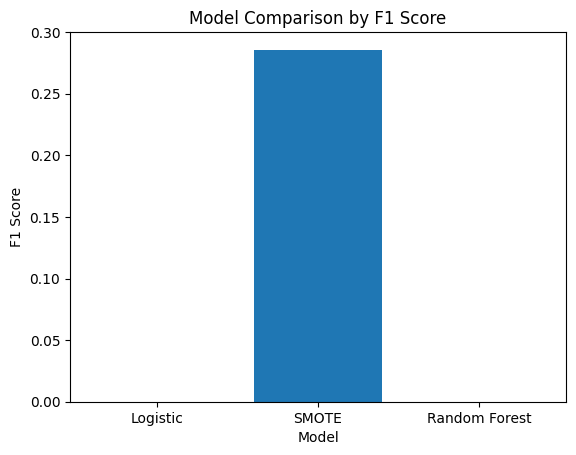

In [8]:
f1_scores = {
    "Logistic": lr_results["f1_score"],
    "SMOTE": smote_results["f1_score"],
    "Random Forest": rf_results["f1_score"]
}

plot_model_f1_scores(f1_scores)

## Mortality Rate by Age Group

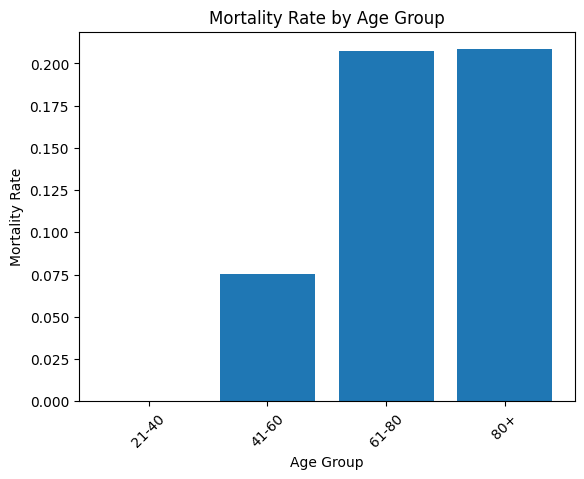

In [9]:
plot_mortality_by_age_group(processor.merged_df)

## Confusion Matrix Visualization

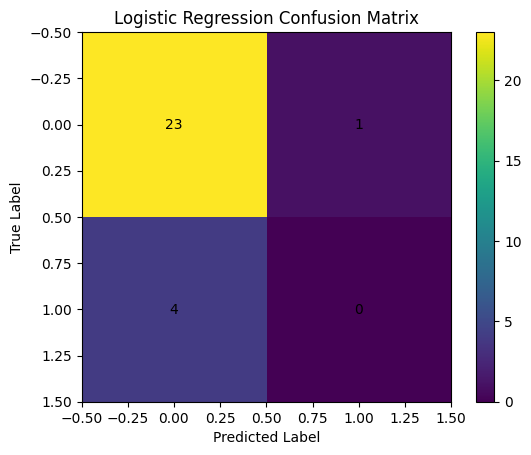

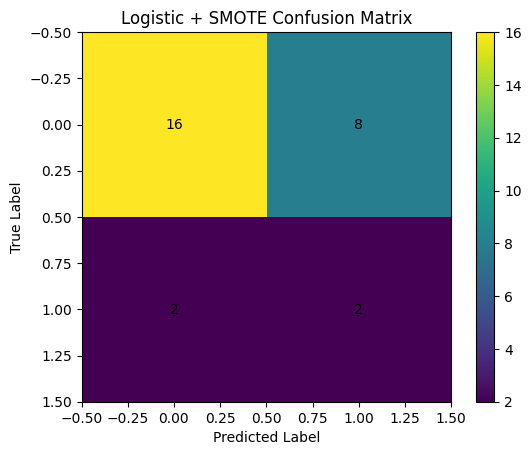

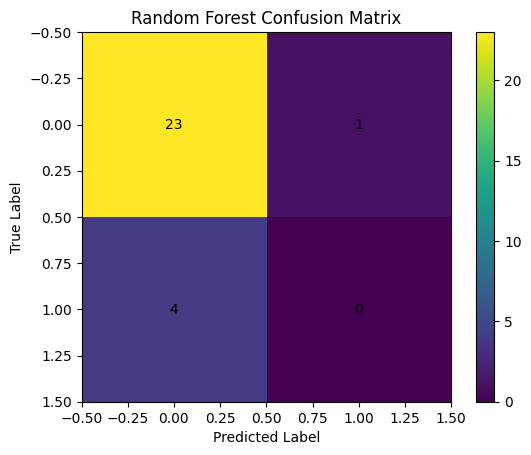

In [10]:
plot_confusion_matrix(lr_results["confusion_matrix"], "Logistic Regression")
plot_confusion_matrix(smote_results["confusion_matrix"], "Logistic + SMOTE")
plot_confusion_matrix(rf_results["confusion_matrix"], "Random Forest")

## Random Forest Feature Importance

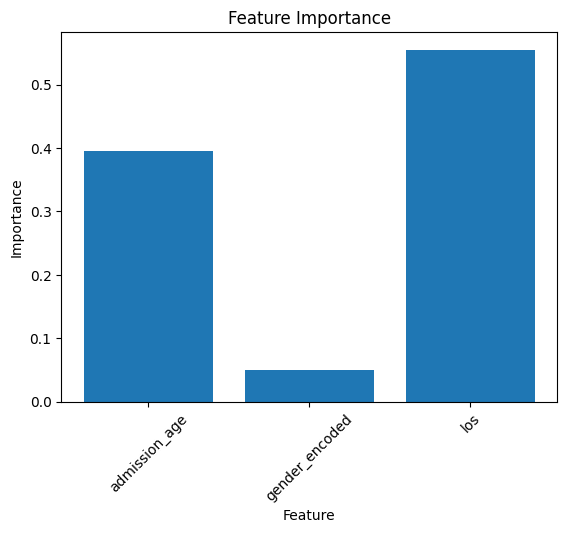

In [11]:
rf_model = predictor.models["random_forest"]
plot_feature_importance(rf_model, predictor.X.columns)

## Export Model Results

In [12]:
results_df = export_model_results(predictor.results)
results_df

,model,accuracy,f1_score,auroc
0,logistic_regression,0.821429,0.000000,0.46875
1,logistic_regression_smote,0.642857,0.285714,0.56250
2,random_forest,0.821429,0.000000,0.56250


## Additional Features (Advanced Python Requirements)

In [13]:
print("\nUnique ICU Units:")
print(processor.get_unique_units())

print("\nRandom Sample:")
print(processor.get_random_sample(5))

print("\nGenerator Output (first 3 rows):")
gen = processor.row_generator()
for _ in range(3):
    print(next(gen))


Unique ICU Units:
['Cardiac Vascular Intensive Care Unit (CVICU)', 'Coronary Care Unit (CCU)', 'Medical Intensive Care Unit (MICU)', 'Medical/Surgical Intensive Care Unit (MICU/SICU)', 'Neuro Intermediate', 'Neuro Stepdown', 'Neuro Surgical Intensive Care Unit (Neuro SICU)', 'Surgical Intensive Care Unit (SICU)', 'Trauma SICU (TSICU)']

Random Sample:
    subject_id gender  anchor_age  anchor_year anchor_year_group        dod  \
28    10002930      F          48         2193       2011 - 2013 2201-12-24   
6     10002428      F          80         2155       2011 - 2013        NaT   
70    10025463      M          66         2136       2011 - 2013 2137-10-09   
62    10015272      F          78         2137       2014 - 2016        NaT   
57    10023239      F          29         2137       2014 - 2016        NaT   

     hadm_id           admittime           dischtime           deathtime  ...  \
28  25696644 2196-04-14 12:25:00 2196-04-17 15:28:00                 NaT  ...   
6   2032